## Packages

In [1]:
import math
from math import sqrt as mS
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter as PF
import seaborn as sns

## Constants & Functions

In [2]:
def createDistDF() :

    """
    List of x, y, and z values

    Parameters:
    None.
    
    Returns:
    df - Dataframe of values.
    """   
    
    a = 2
    Xs = []
    Ys = []
    Z1s = []
    Zips = []
    Zfs = []
    Z2s = []
    
    for x in [i/500 for i in range(501)] :
        for y in [j/500 for j in range(501)] :
            
            #All three targets, 9 outcomes.
            no_strategy =  (2*x*x + y*y) / 9 
            #Indistinguishiable pair only, 4 outcomes.
            ind_pair = x*x / 2
            #Far away only, 1 outcome.
            far = y*y
            Xs.append(x)
            Ys.append(y)
            Z1s.append(no_strategy)
            Zips.append(ind_pair)
            Zfs.append(far)
            Z2s.append(max(ind_pair, far))
            
    df = pd.DataFrame({'X' : Xs,
                       'Y' : Ys,
                       'Z1' : Z1s,
                       'Zips' : Zips,
                       'Zfs' : Zfs,
                       'Z2' : Z2s})
    return(df)





def heatMap(Z) :
    fig = plt.figure(figsize = (10, 8))  
    ax = fig.add_subplot(xlim = (0, 1),
                         ylim = (0, 1))
    fig.subplots_adjust(left = 0.02, bottom = 0.02, right = 0.98, top = 0.98)
    
    df = createDistDF()
   
    cmap = plt.cm.viridis_r
    
    heatmap = plt.scatter(x = df['X'],
                          y = df['Y'],
                          c = df['Z' + str(Z)],
                          cmap = cmap,
                          marker = "s",
                          s = 1,
                          vmin = 0,
                          vmax = 1,
                          plotnonfinite = True)
    #Title setup.
    ax.set_title('Can the Archers Coordinate?', fontsize = 24)

    #X-axis setup.
    ax.set_xlabel("Two, Closer, Indistinguishable Targets", fontsize = 22)
    ax.xaxis.set_major_formatter(PF(xmax = 1))
    #Y-axis setup.
    ax.set_ylabel("Further Away Target", fontsize = 22)
    ax.yaxis.set_major_formatter(PF(xmax = 1))
    ax.tick_params(axis = 'both', which = 'major', labelsize = 16)
        
    if Z == 2:
        
        #50% & 25% cutoffs and line of equality.
        a = 0
        b = 0.5
        c = 1/mS(2)
        d = 1
    
        for x, y in [([a, d], [c, c]),
                     ([a, c], [b, b]),
                     ([a, d], [a, c]),
                     ([c, c], [0, b])] :
        
            ax.plot(x,y,
                    lw = 1,
                    c = 'k',
                    ls = '--')
    
    
        text = [("y ≈ 100%, P = 100%", (b, 0.97), 'k', 0),
                ("y ≈ 70.71%, P = 50%", (b, 0.68), 'k', 0),
                ("y = 50%, P = 25%", (c/2, 0.47), 'k', 0),
                ("y = x/√2", (b, c/2), 'k', 35.264),
                ("x = 100%, P = 50%", (0.98, 0.2), 'k', -90),
                ("x = 70.71%, P = 25%", (0.68, 0.1), 'k', -90)]
         
        for t in text :
            
            plt.annotate(text = t[0],
                         xy = t[1],
                         c = t[2],
                         size = 14,
                         ha = 'center',
                         rotation = t[3],
                         zorder = 4)
   
    #Colorbar.
    cb = plt.colorbar(heatmap, ax = ax, format = PF(xmax = 1))
    cb.set_label('Prize Win %',
                 labelpad = -100,
                 fontsize = 20)
    cb.ax.tick_params(labelsize = 16)

    
    fig.savefig("2026.02.20 EC" + str(Z) + ".png", bbox_inches = "tight")

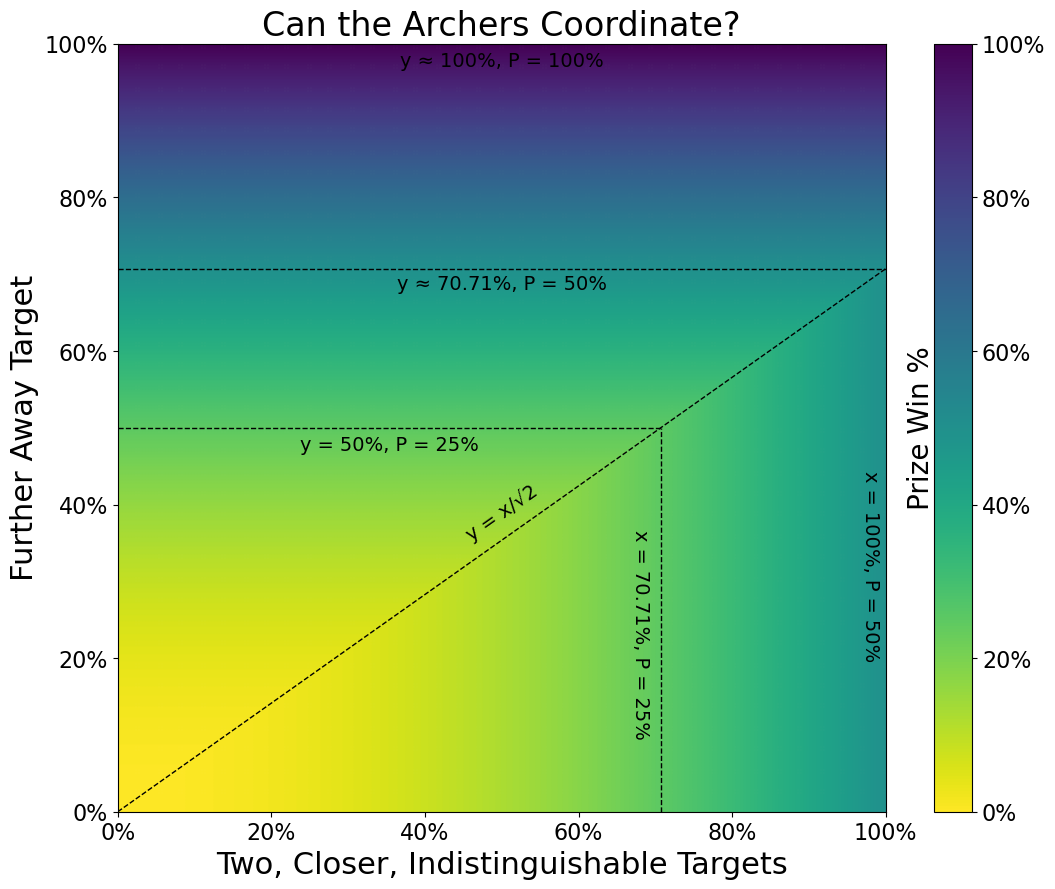

In [3]:
heatMap(2)

# Rohan Lewis

#### 2026.02.23